In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import svm
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder,OrdinalEncoder
import warnings
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
import pickle
from sklearn.pipeline import Pipeline
%matplotlib inline
warnings.filterwarnings('ignore')


In [3]:
df=pd.read_csv("C:/Users/Tanmay Patel/Desktop/CDS/CDS/Feature Engineering/loan.csv")
df.head()

,ID,Loan Amount,Funded Amount,Funded Amount Investor,Term,Batch Enrolled,Interest Rate,Grade,Sub Grade,Employment Duration,...,Marital Status,Education Level,Employment Type,Property Value,Collateral,Bankruptcy History,Housing Type,Years in Current Job,Savings Amount,Risk Score
0,65087372,10000,32236,12329.36286,59,BAT2522922,11.135007,B,C4,MORTGAGE,...,Divorced,Master's,Unemployed,52764,No,0,Owned,33,190445,0.216437
1,1450153,3609,11940,12191.99692,59,BAT1586599,12.237563,C,D3,RENT,...,Single,Bachelor's,Salaried,500995,No,1,Owned,33,131852,0.677130
2,1969101,28276,9311,21603.22455,59,BAT2136391,12.545884,F,D4,MORTGAGE,...,Divorced,Bachelor's,Unemployed,291172,Yes,1,Rented,35,174644,0.981313
3,6651430,11170,6954,17877.15585,59,BAT2428731,16.731201,C,C3,MORTGAGE,...,Single,Master's,Salaried,933714,No,0,Mortgaged,33,61604,0.399829
4,14354669,16890,13226,13539.92667,59,BAT5341619,15.008300,C,D4,MORTGAGE,...,Divorced,PhD,Unemployed,353721,No,0,Owned,22,94529,0.492224


In [4]:
df.shape


(67463, 55)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67463 entries, 0 to 67462
Data columns (total 55 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            67463 non-null  int64  
 1   Loan Amount                   67463 non-null  int64  
 2   Funded Amount                 67463 non-null  int64  
 3   Funded Amount Investor        67463 non-null  float64
 4   Term                          67463 non-null  int64  
 5   Batch Enrolled                67463 non-null  object 
 6   Interest Rate                 67463 non-null  float64
 7   Grade                         67463 non-null  object 
 8   Sub Grade                     67463 non-null  object 
 9   Employment Duration           67463 non-null  object 
 10  Home Ownership                67463 non-null  float64
 11  Verification Status           67463 non-null  object 
 12  Payment Plan                  67463 non-null  object 
 13  L

In [6]:
df.isnull().sum()

ID                              0
Loan Amount                     0
Funded Amount                   0
Funded Amount Investor          0
Term                            0
Batch Enrolled                  0
Interest Rate                   0
Grade                           0
Sub Grade                       0
Employment Duration             0
Home Ownership                  0
Verification Status             0
Payment Plan                    0
Loan Title                      0
Debit to Income                 0
Delinquency - two years         0
Inquires - six months           0
Open Account                    0
Public Record                   0
Revolving Balance               0
Revolving Utilities             0
Total Accounts                  0
Initial List Status             0
Total Received Interest         0
Total Received Late Fee         0
Recoveries                      0
Collection Recovery Fee         0
Collection 12 months Medical    0
Application Type                0
Last week Pay 

In [7]:
# This all columns are not important that's why we are going to drop mentioned
df=df.drop(["ID","Loan Title","Batch Enrolled","Initial List Status",
            "Application Type","Last week Pay"], axis=1)
df


,Loan Amount,Funded Amount,Funded Amount Investor,Term,Interest Rate,Grade,Sub Grade,Employment Duration,Home Ownership,Verification Status,...,Marital Status,Education Level,Employment Type,Property Value,Collateral,Bankruptcy History,Housing Type,Years in Current Job,Savings Amount,Risk Score
0,10000,32236,12329.36286,59,11.135007,B,C4,MORTGAGE,176346.62670,Not Verified,...,Divorced,Master's,Unemployed,52764,No,0,Owned,33,190445,0.216437
1,3609,11940,12191.99692,59,12.237563,C,D3,RENT,39833.92100,Source Verified,...,Single,Bachelor's,Salaried,500995,No,1,Owned,33,131852,0.677130
2,28276,9311,21603.22455,59,12.545884,F,D4,MORTGAGE,91506.69105,Source Verified,...,Divorced,Bachelor's,Unemployed,291172,Yes,1,Rented,35,174644,0.981313
3,11170,6954,17877.15585,59,16.731201,C,C3,MORTGAGE,108286.57590,Source Verified,...,Single,Master's,Salaried,933714,No,0,Mortgaged,33,61604,0.399829
4,16890,13226,13539.92667,59,15.008300,C,D4,MORTGAGE,44234.82545,Source Verified,...,Divorced,PhD,Unemployed,353721,No,0,Owned,22,94529,0.492224
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67458,13601,6848,13175.28583,59,9.408858,C,A4,MORTGAGE,83961.15003,Verified,...,Single,Master's,Self-Employed,814874,No,0,Owned,31,24996,0.646428
67459,8323,11046,15637.46301,59,9.972104,C,B3,RENT,65491.12817,Source Verified,...,Divorced,Bachelor's,Self-Employed,61136,Yes,1,Owned,33,196210,0.066679
67460,15897,32921,12329.45775,59,19.650943,A,F3,MORTGAGE,34813.96985,Verified,...,Widowed,Master's,Salaried,190451,Yes,1,Rented,30,136420,0.916311
67461,16567,4975,21353.68465,59,13.169095,D,E3,OWN,96938.83564,Not Verified,...,Single,PhD,Salaried,553361,No,0,Mortgaged,30,52979,0.681814


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67463 entries, 0 to 67462
Data columns (total 49 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Loan Amount                   67463 non-null  int64  
 1   Funded Amount                 67463 non-null  int64  
 2   Funded Amount Investor        67463 non-null  float64
 3   Term                          67463 non-null  int64  
 4   Interest Rate                 67463 non-null  float64
 5   Grade                         67463 non-null  object 
 6   Sub Grade                     67463 non-null  object 
 7   Employment Duration           67463 non-null  object 
 8   Home Ownership                67463 non-null  float64
 9   Verification Status           67463 non-null  object 
 10  Payment Plan                  67463 non-null  object 
 11  Debit to Income               67463 non-null  float64
 12  Delinquency - two years       67463 non-null  int64  
 13  I

In [9]:
df.describe() 

,Loan Amount,Funded Amount,Funded Amount Investor,Term,Interest Rate,Home Ownership,Debit to Income,Delinquency - two years,Inquires - six months,Open Account,...,Co-Applicant Income,Previous Defaults,Current Liabilities,Loan Tenure,Debt-to-Income Ratio,Property Value,Bankruptcy History,Years in Current Job,Savings Amount,Risk Score
count,67463.000000,67463.000000,67463.000000,67463.000000,67463.000000,67463.000000,67463.000000,67463.000000,67463.000000,67463.000000,...,67463.000000,67463.000000,67463.000000,67463.000000,67463.000000,67463.000000,67463.000000,67463.000000,67463.000000,67463.000000
mean,16848.902776,15770.599114,14621.799323,58.173814,11.846258,80541.502522,23.299241,0.327127,0.145754,14.266561,...,25025.031187,0.500319,100330.791664,36.139632,0.551292,524607.611165,0.500156,19.455865,100058.774291,0.499907
std,8367.865726,8150.992662,6785.345170,3.327441,3.718629,45029.120366,8.451824,0.800888,0.473291,6.225060,...,14463.454769,0.500004,57803.314058,16.970680,0.259299,273754.656614,0.500004,11.534250,57507.407579,0.287944
min,1014.000000,1014.000000,1114.590204,36.000000,5.320006,14573.537170,0.675299,0.000000,0.000000,2.000000,...,1.000000,0.000000,0.000000,12.000000,0.100000,50032.000000,0.000000,0.000000,3.000000,0.000007
25%,10012.000000,9266.500000,9831.684984,58.000000,9.297147,51689.843335,16.756416,0.000000,0.000000,10.000000,...,12529.500000,0.000000,50436.500000,24.000000,0.325675,289772.000000,0.000000,9.000000,50649.000000,0.251583
50%,16073.000000,13042.000000,12793.682170,59.000000,11.377696,69335.832680,22.656658,0.000000,0.000000,13.000000,...,25027.000000,1.000000,100296.000000,36.000000,0.553354,524387.000000,1.000000,19.000000,100158.000000,0.500115
75%,22106.000000,21793.000000,17807.594120,59.000000,14.193533,94623.322785,30.048400,0.000000,0.000000,16.000000,...,37528.500000,1.000000,150455.000000,48.000000,0.775468,762023.000000,1.000000,29.000000,149414.000000,0.749021
max,35000.000000,34999.000000,34999.746430,59.000000,27.182348,406561.536400,39.629862,8.000000,5.000000,37.000000,...,49999.000000,1.000000,199998.000000,60.000000,0.999998,999980.000000,1.000000,39.000000,199994.000000,0.999986


# Checking for outliers '
# Correlation Matrix '

In [11]:
df

,Loan Amount,Funded Amount,Funded Amount Investor,Term,Interest Rate,Grade,Sub Grade,Employment Duration,Home Ownership,Verification Status,...,Marital Status,Education Level,Employment Type,Property Value,Collateral,Bankruptcy History,Housing Type,Years in Current Job,Savings Amount,Risk Score
0,10000,32236,12329.36286,59,11.135007,B,C4,MORTGAGE,176346.62670,Not Verified,...,Divorced,Master's,Unemployed,52764,No,0,Owned,33,190445,0.216437
1,3609,11940,12191.99692,59,12.237563,C,D3,RENT,39833.92100,Source Verified,...,Single,Bachelor's,Salaried,500995,No,1,Owned,33,131852,0.677130
2,28276,9311,21603.22455,59,12.545884,F,D4,MORTGAGE,91506.69105,Source Verified,...,Divorced,Bachelor's,Unemployed,291172,Yes,1,Rented,35,174644,0.981313
3,11170,6954,17877.15585,59,16.731201,C,C3,MORTGAGE,108286.57590,Source Verified,...,Single,Master's,Salaried,933714,No,0,Mortgaged,33,61604,0.399829
4,16890,13226,13539.92667,59,15.008300,C,D4,MORTGAGE,44234.82545,Source Verified,...,Divorced,PhD,Unemployed,353721,No,0,Owned,22,94529,0.492224
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67458,13601,6848,13175.28583,59,9.408858,C,A4,MORTGAGE,83961.15003,Verified,...,Single,Master's,Self-Employed,814874,No,0,Owned,31,24996,0.646428
67459,8323,11046,15637.46301,59,9.972104,C,B3,RENT,65491.12817,Source Verified,...,Divorced,Bachelor's,Self-Employed,61136,Yes,1,Owned,33,196210,0.066679
67460,15897,32921,12329.45775,59,19.650943,A,F3,MORTGAGE,34813.96985,Verified,...,Widowed,Master's,Salaried,190451,Yes,1,Rented,30,136420,0.916311
67461,16567,4975,21353.68465,59,13.169095,D,E3,OWN,96938.83564,Not Verified,...,Single,PhD,Salaried,553361,No,0,Mortgaged,30,52979,0.681814


In [12]:
df.columns

Index(['Loan Amount', 'Funded Amount', 'Funded Amount Investor', 'Term',
       'Interest Rate', 'Grade', 'Sub Grade', 'Employment Duration',
       'Home Ownership', 'Verification Status', 'Payment Plan',
       'Debit to Income', 'Delinquency - two years', 'Inquires - six months',
       'Open Account', 'Public Record', 'Revolving Balance',
       'Revolving Utilities', 'Total Accounts', 'Total Received Interest',
       'Total Received Late Fee', 'Recoveries', 'Collection Recovery Fee',
       'Collection 12 months Medical', 'Accounts Delinquent',
       'Total Collection Amount', 'Total Current Balance',
       'Total Revolving Credit Limit', 'Loan Status', 'Credit Score',
       'Loan Purpose', 'Income Stability', 'Monthly Expenses', 'Dependents',
       'Co-Applicant Income', 'Previous Defaults', 'Current Liabilities',
       'Loan Tenure', 'Debt-to-Income Ratio', 'Marital Status',
       'Education Level', 'Employment Type', 'Property Value', 'Collateral',
       'Bankruptcy His

In [13]:

col=['Loan Amount','Funded Amount','Funded Amount Investor','Interest Rate','Home Ownership','Debit to Income','Delinquency - two years','Revolving Balance','Revolving Utilities','Total Accounts','Total Received Interest','Total Received Late Fee','Recoveries','Collection Recovery Fee','Total Collection Amount','Total Current Balance','Total Revolving Credit Limit','Credit Score','Monthly Expenses','Co-Applicant Income','Current Liabilities','Debt-to-Income Ratio','Property Value','Years in Current Job','Savings Amount','Risk Score']
col




['Loan Amount',
 'Funded Amount',
 'Funded Amount Investor',
 'Interest Rate',
 'Home Ownership',
 'Debit to Income',
 'Delinquency - two years',
 'Revolving Balance',
 'Revolving Utilities',
 'Total Accounts',
 'Total Received Interest',
 'Total Received Late Fee',
 'Recoveries',
 'Collection Recovery Fee',
 'Total Collection Amount',
 'Total Current Balance',
 'Total Revolving Credit Limit',
 'Credit Score',
 'Monthly Expenses',
 'Co-Applicant Income',
 'Current Liabilities',
 'Debt-to-Income Ratio',
 'Property Value',
 'Years in Current Job',
 'Savings Amount',
 'Risk Score']

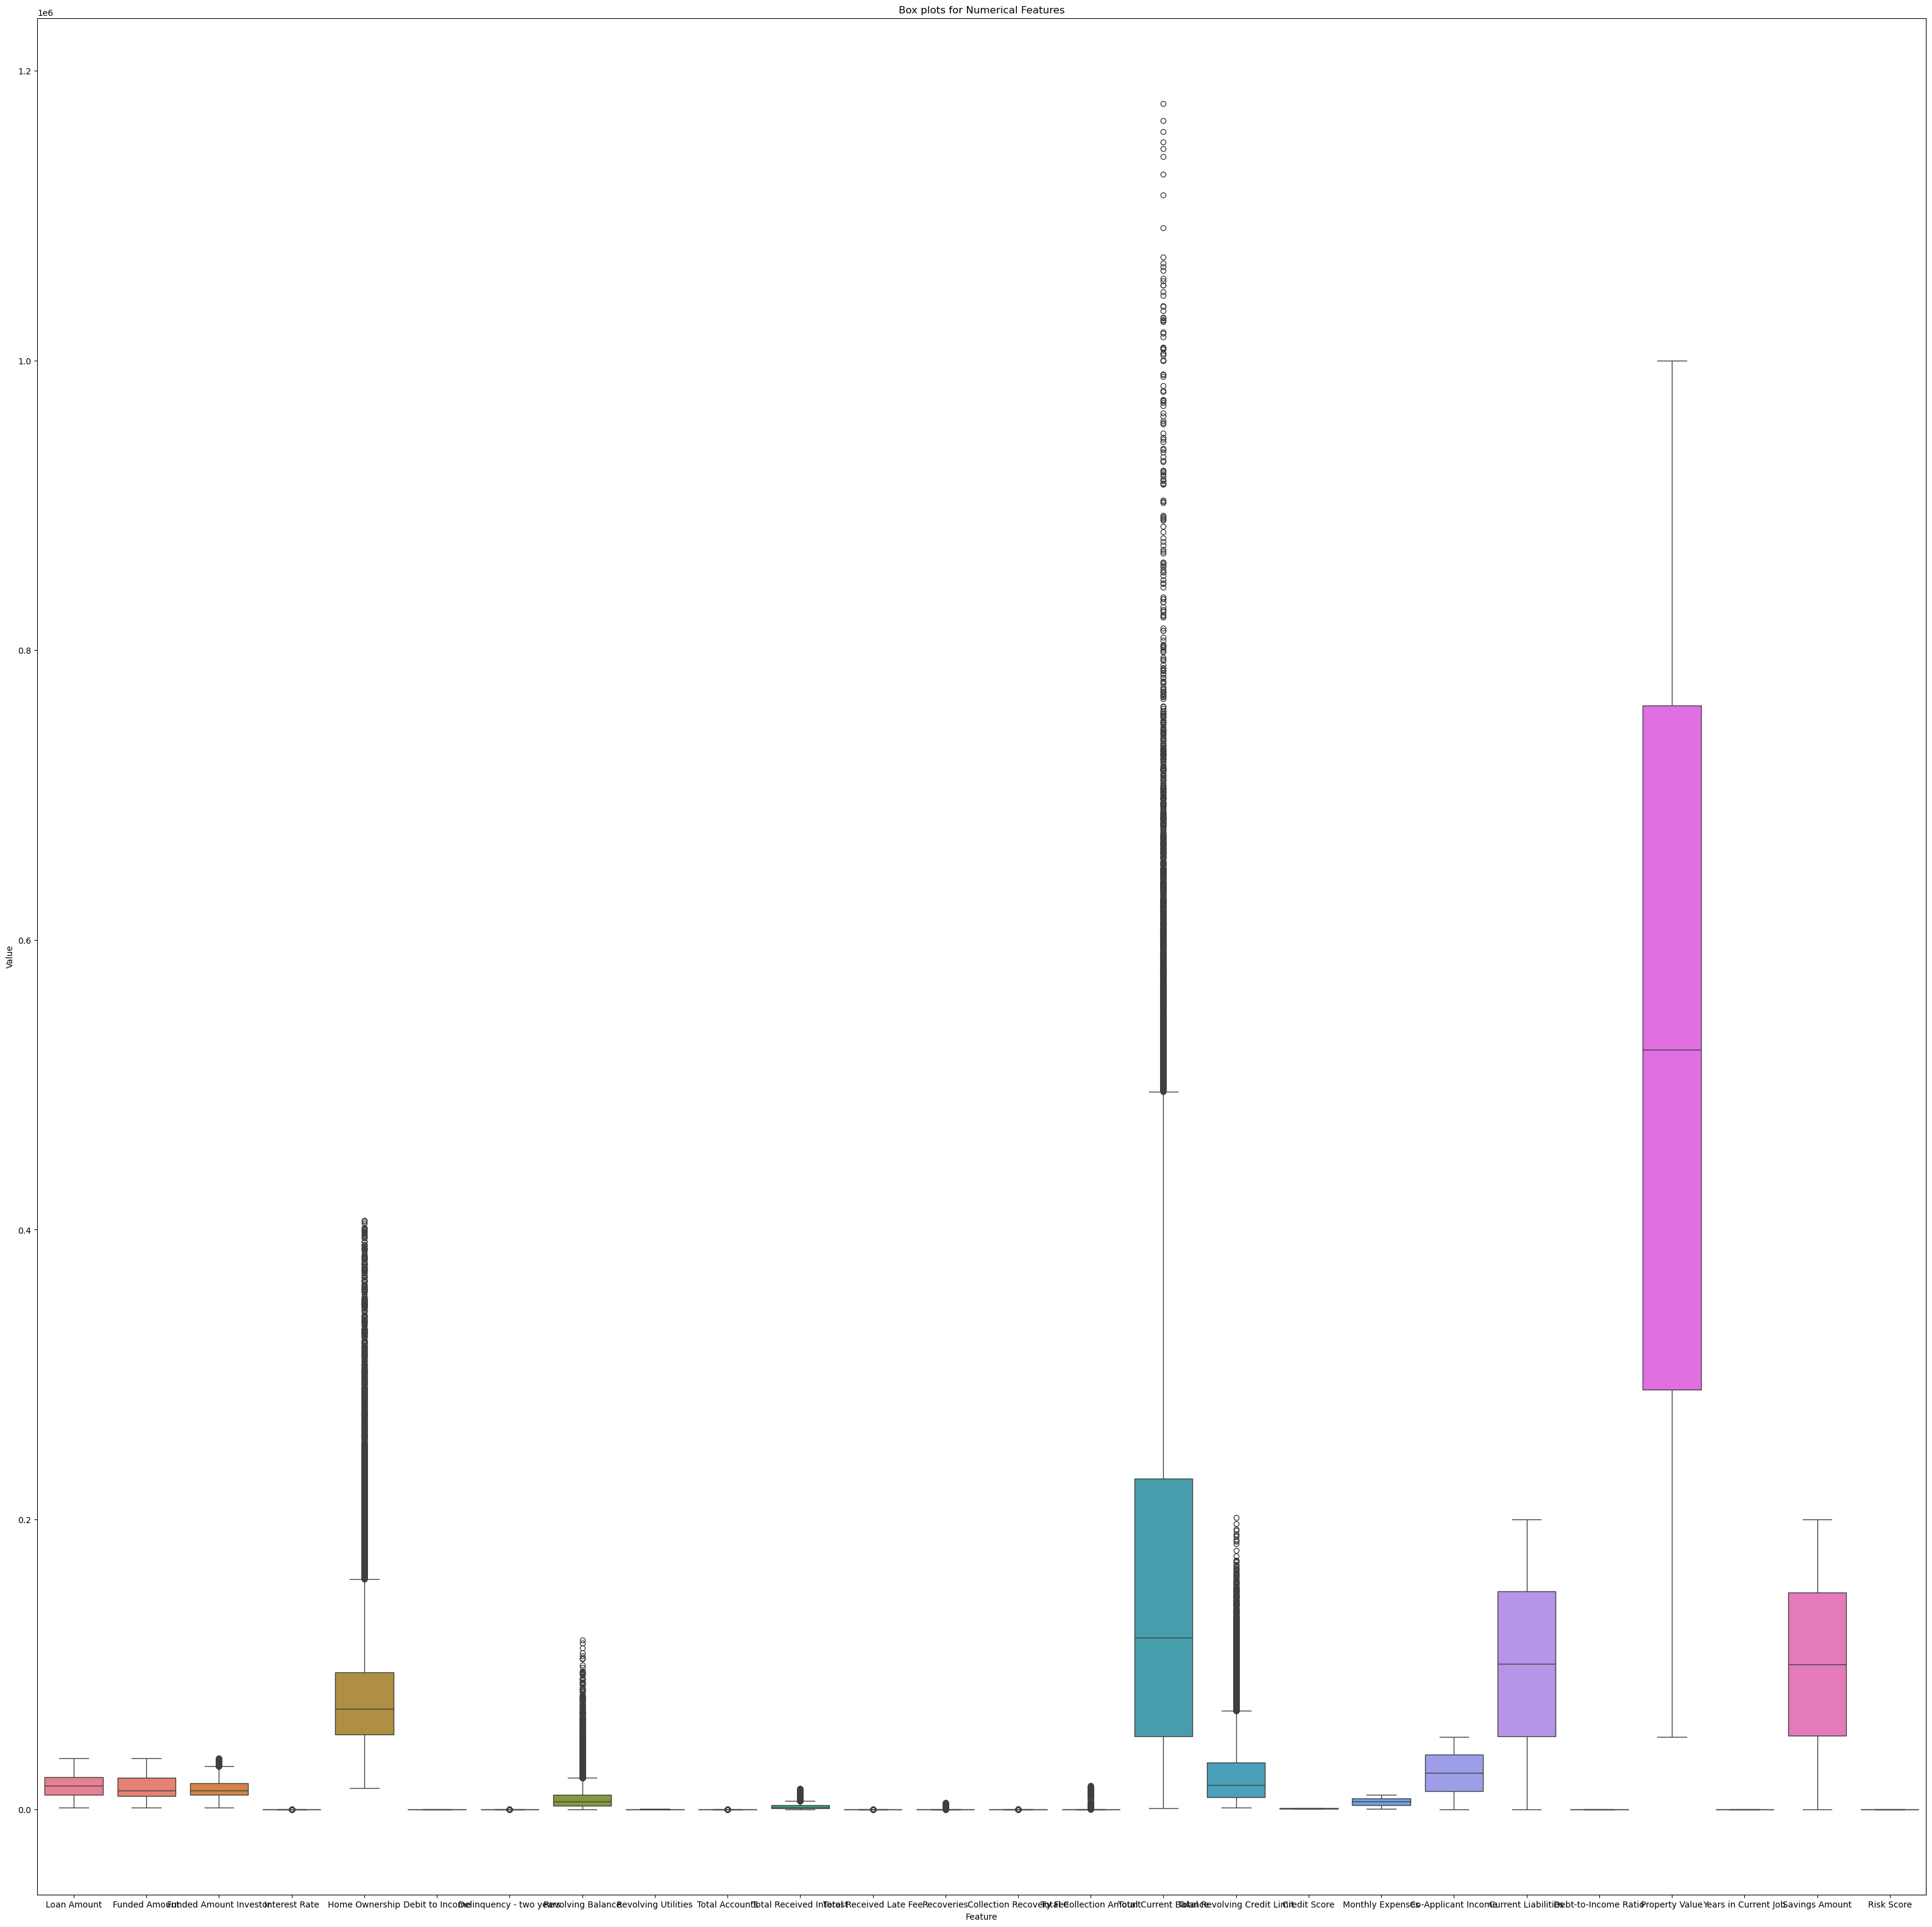

In [14]:
data_list=[]
for i in df[col]:
    data_list.append(df[i])

plt.figure(figsize=(40,40))
sns.boxplot(data_list)
plt.title('Box plots for Numerical Features')
plt.ylabel('Value')
plt.xlabel('Feature')
plt.show()

# Select numerical columns
#numerical_cols = df.select_dtypes(include=['int', 'float']).columns

# Create box plots for all numerical features
#plt.figure(figsize=(40, 40))
#df[col].boxplot()
#plt.xticks(rotation=45)
#plt.title('Box plots for Numerical Features')
#plt.ylabel('Value')
#plt.xlabel('Feature')
#plt.show()

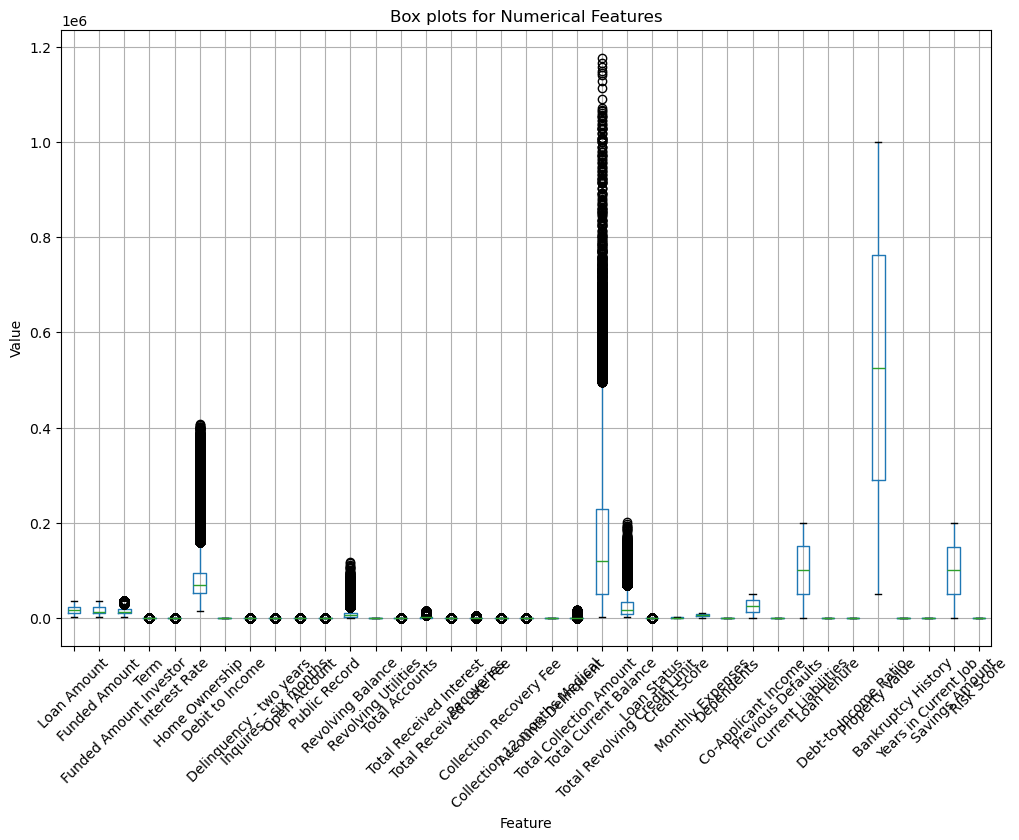

In [15]:
# Select numerical columns
numerical_cols = df.select_dtypes(include=['int', 'float']).columns

# Create box plots for all numerical features
plt.figure(figsize=(12, 8))
df[numerical_cols].boxplot()
plt.xticks(rotation=45)
plt.title('Box plots for Numerical Features')
plt.ylabel('Value')
plt.xlabel('Feature')
plt.show()

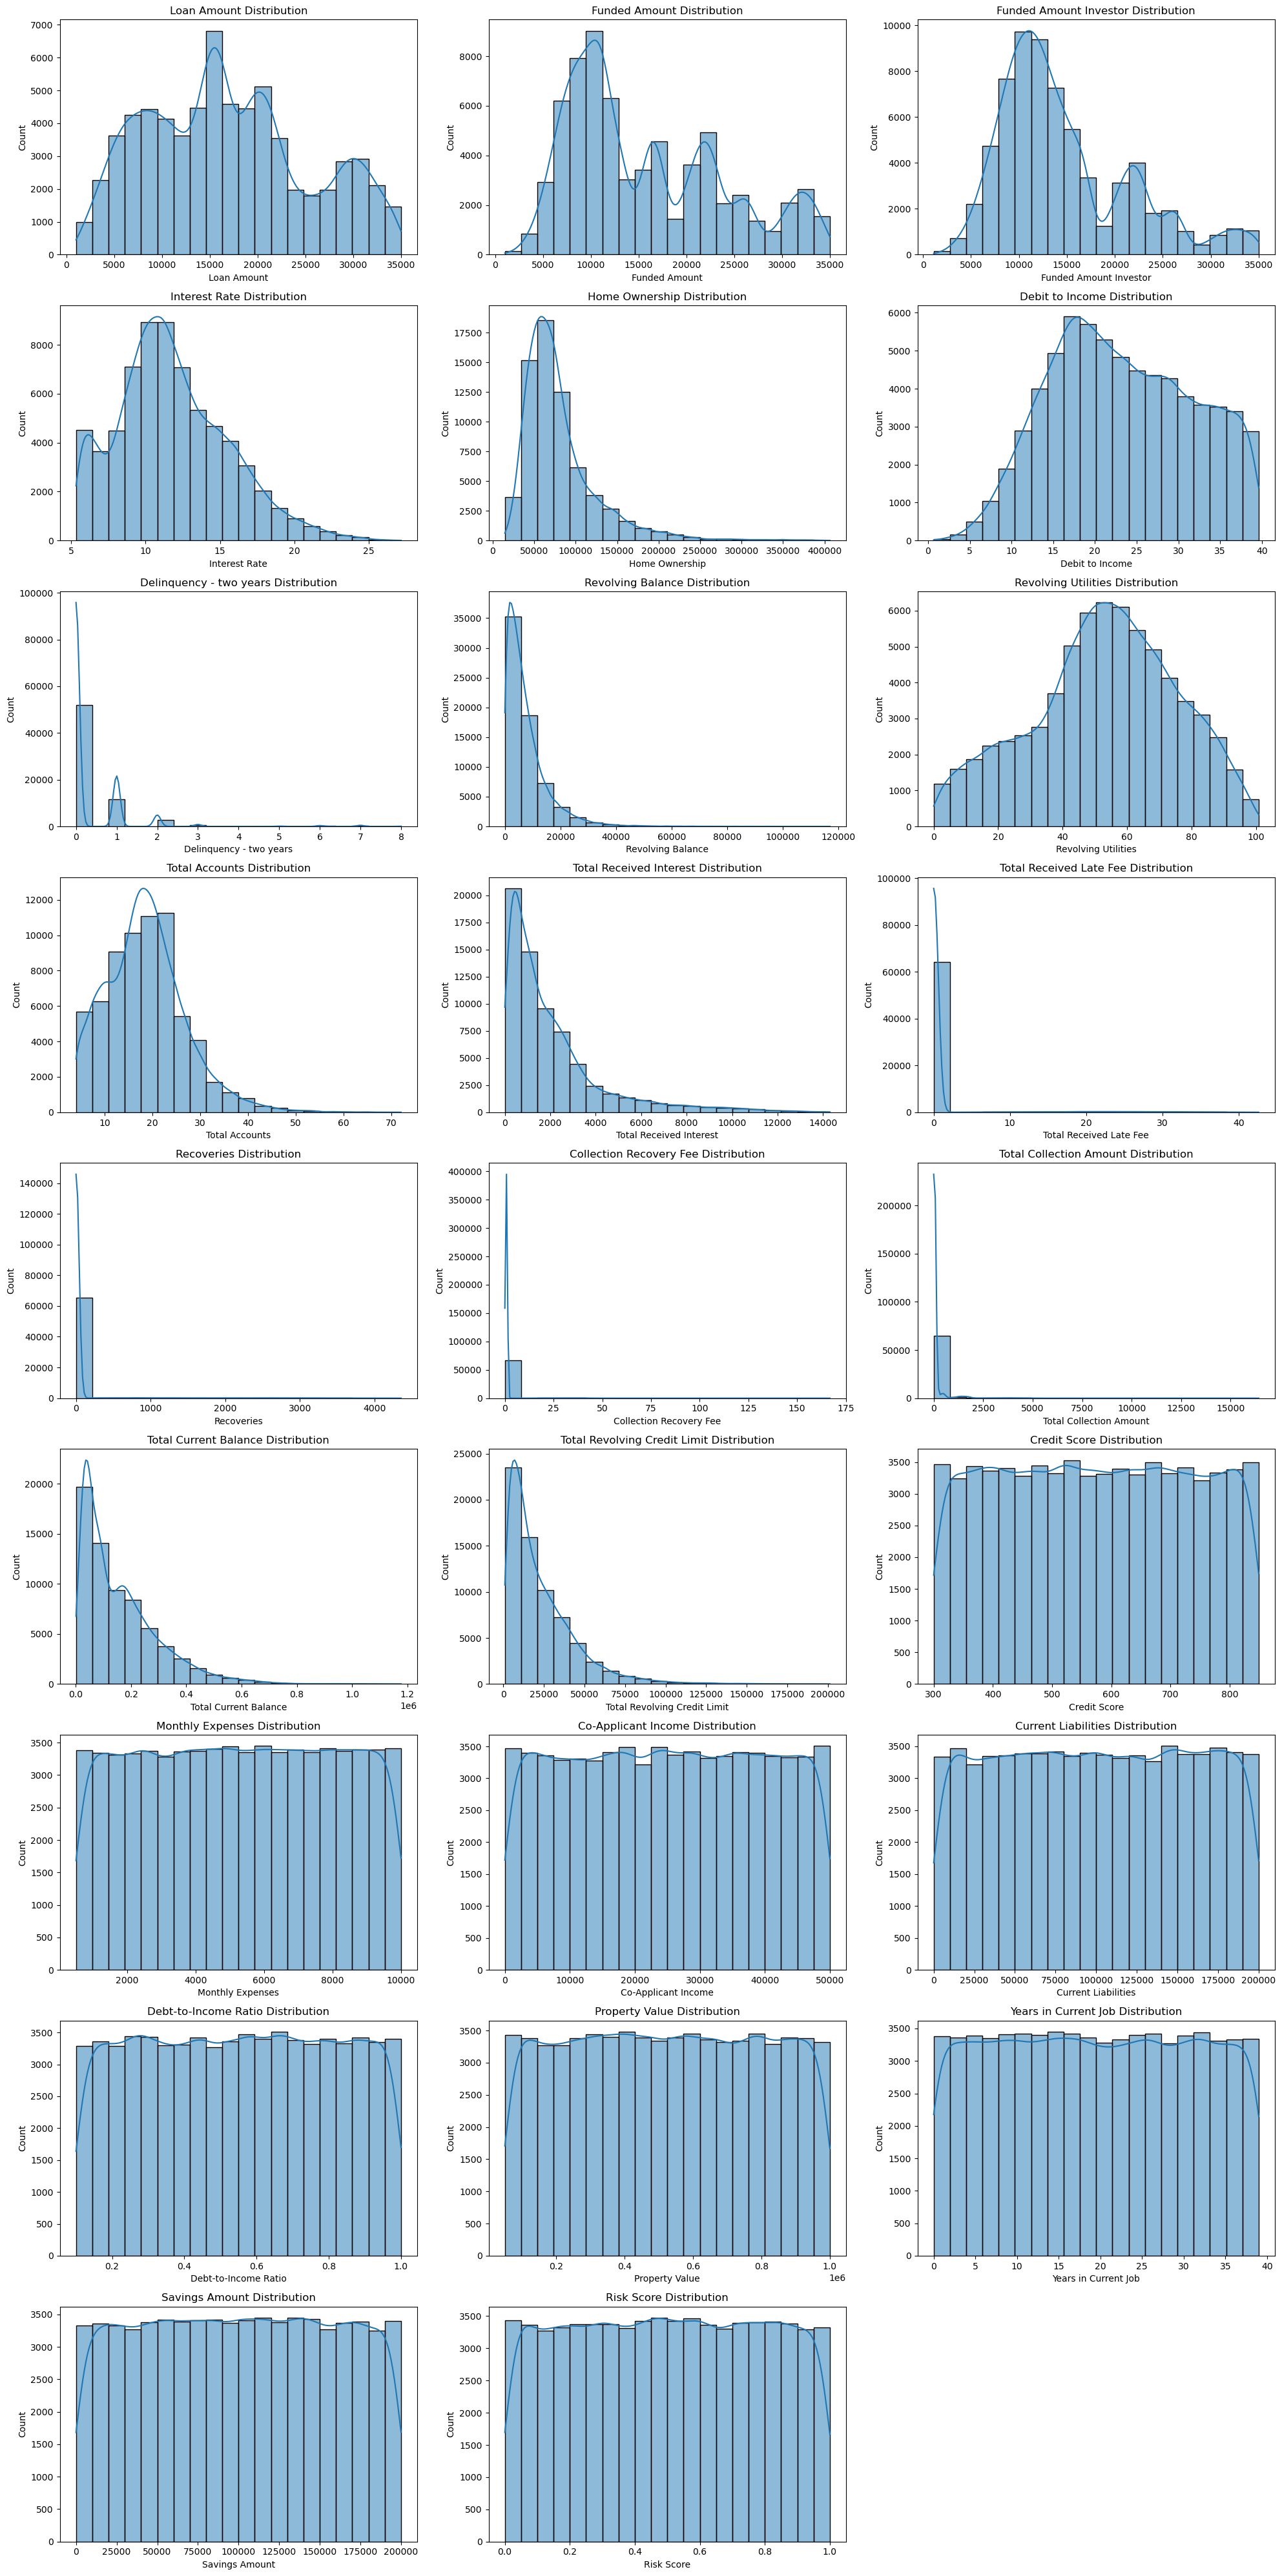

In [16]:
pltn = 1
plt.figure(figsize=(20,40))

for i in df[col]:
    plt.subplot(9,3,pltn)
    sns.histplot(df[i],kde=True,bins=20)
    plt.title(f'{i} Distribution')
    pltn = pltn + 1
plt.tight_layout()
plt.show()

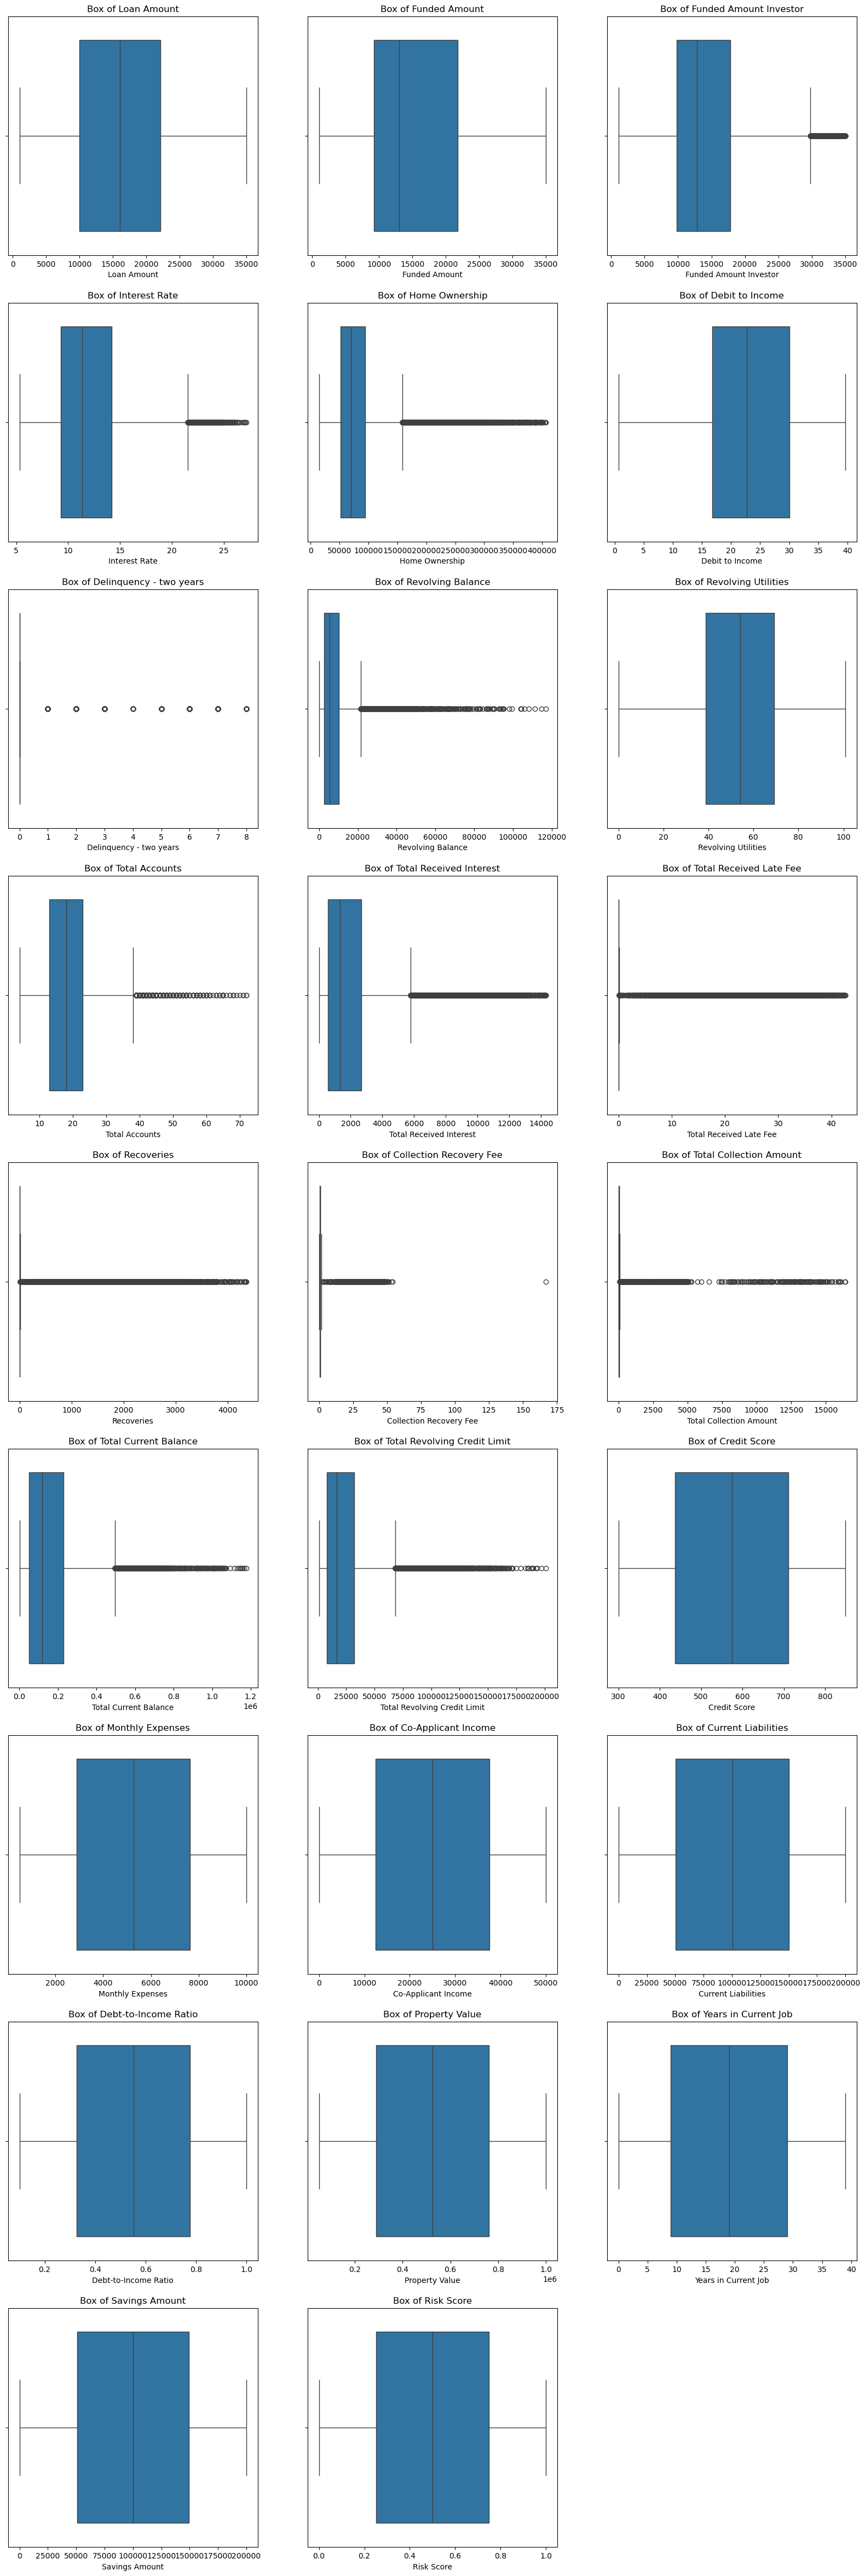

In [17]:
plt.figure(figsize=(20, 60))
plot = 1

for i in col:   
    plt.subplot(9, 3, plot)
    sns.boxplot(x=df[i])   
    plt.title(f"Box of {i}")
    plot += 1
plt.show()

* # outlayers=["Funded Amount Investor","Interest Rate","Home Ownership","Revolving Balance","Total Accounts","Total Received Interest","Total Received Late Fee","Recoveries","Collection Recovery Fee","Total Collection Amount","Total Current Balance","Total Revolving Credit"," Limit"]
  *

In [19]:
# We are defining here each columns that which scaling techniques are used for which columns :

ohe=["Employment Duration","Loan Purpose","Marital Status","Education Level","Employment Type","Housing Type",]
oridnal=OrdinalEncoder(categories=[["G",'F','E','D','C','B','A']])
label=["Verification Status","Income Stability","Collateral"]
minmax=["Loan Amount","Funded Amount","Funded Amount Investor","Interest Rate","Home Ownership","Debit to Income","Open Account",
        "Revolving Balance","Revolving Utilities","Total Accounts","Total Received Interest","Total Received Late Fee","Recoveries","Collection Recovery Fee",
        "Total Collection Amount","Total Current Balance","Total Revolving Credit Limit","Credit Score","Monthly Expenses","Dependents","Co-Applicant Income","Previous Defaults",
        "Current Liabilities","Loan Tenure","Debt-to-Income Ratio","Debt-to-Income Ratio","Property Value","Years in Current Job","Savings Amount","Risk Score"]
passthrough=["Delinquency - two years","Inquires - six months","Public Record","Loan Status","Bankruptcy History"]
function_transformer=["Loan Tenure"]


In [20]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder,OrdinalEncoder,MinMaxScaler

# Lable encoding
## Column Transformer :

In [22]:
class ModifiedLabelEncoder(LabelEncoder):
    def fit_transform(self, y, *args, **kwargs):
        return super().fit_transform(y).reshape(-1, 1)

    def transform(self, y, *args, **kwargs):
        return super().transform(y).reshape(-1, 1)

# Function Transformer#

In [24]:
def divide(x):
    return (x/12)
custom=FunctionTransformer(divide)

# passthrought

In [26]:
def same(x):
    return x
no_trans=FunctionTransformer(same)

# Defining the preprocessor :

In [28]:
preprocessor=ColumnTransformer([('ohe',OneHotEncoder(),ohe),
                                ('minmax',MinMaxScaler(),minmax),
                                ('Pass_through',no_trans,passthrough),
                                 ('custom',custom,function_transformer),
                                ('Label_encoder1',ModifiedLabelEncoder(),["Verification Status"]),
                                ('Label_encoder2',ModifiedLabelEncoder(),["Income Stability"]),
                                ('Label_encoder',ModifiedLabelEncoder(),["Collateral"]),
                                ("ordinal",oridnal,['Grade'])])
                                

In [29]:
preprocessor

ColumnTransformer(transformers=[('ohe', OneHotEncoder(),
                                 ['Employment Duration', 'Loan Purpose',
                                  'Marital Status', 'Education Level',
                                  'Employment Type', 'Housing Type']),
                                ('minmax', MinMaxScaler(),
                                 ['Loan Amount', 'Funded Amount',
                                  'Funded Amount Investor', 'Interest Rate',
                                  'Home Ownership', 'Debit to Income',
                                  'Open Account', 'Revolving Balance',
                                  'Revolving Utilities', 'Total Accounts'...
                                ('custom',
                                 FunctionTransformer(func=<function divide at 0x00000217E44B0860>),
                                 ['Loan Tenure']),
                                ('Label_encoder1', ModifiedLabelEncoder(),
                                 ['Verification Status']),
                                ('Label_encoder2', ModifiedLabelEncoder(),
                                 ['Income Stability']),
                                ('Label_encoder', ModifiedLabelEncoder(),
                                 ['Collateral']),
                                ('ordinal',
                                 OrdinalEncoder(categories=[['G', 'F', 'E', 'D',
                                                             'C', 'B', 'A']]),
                                 ['Grade'])])

In [30]:
file=open("cust_lone.pkl","wb")
pickle.dump(preprocessor,file)
file.close()
